# Python Foundations Project: Austo



## Problem Statement

### Context

In the 21st century, cars are an important mode of transportation that provides us the opportunity for personal control and autonomy. In day-to-day life, people use cars for commuting to work, shopping, visiting family and friends, etc. Research shows that more than 76% of people prevent themselves from traveling somewhere if they don't have a car. Most people tend to buy different types of cars based on their day-to-day necessities and preferences. So, it is essential for automobile companies to analyze the preference of their customers before launching a car model into the market. Austo, a UK-based automobile company aspires to grow its business into the US market after successfully establishing its footprints in the European market.

In order to be familiar with the types of cars preferred by the customers and factors influencing the car purchase behavior in the US market, Austo has contracted a consulting firm. Based on various market surveys, the consulting firm has created a dataset of 3 major types of cars that are extensively used across the US market. They have collected various details of the car owners which can be analyzed to understand the automobile market of the US.

### Objective

Austo's management team wants to understand the demand of the buyers and trends in the US market. They want to build customer profiles based on the analysis to identify new purchase opportunities so that they can manipulate the business strategy and production to meet certain demand levels. Further, the analysis will be a good way for management to understand the dynamics of a new market. Suppose you are a Data Scientist working at the consulting firm that has been contracted by Austo. You are given the task to create buyer's profiles for different types of cars with the available data as well as a set of recommendations for Austo. Perform the data analysis to generate useful insights that will help the automobile company to grow its business.

### Data Description

austo_automobile.csv: The dataset contains buyer's data corresponding to different types of products(cars).

### Data Dictionary

* Age: Age of the customer
* Gender: Gender of the customer
* Profession: Indicates whether the customer is a salaried or business person
* Marital_status: Marital status of the customer
* Education: Refers to the highest level of education completed by the customer
* No_of_dependents: Number of dependents(partner/children/spouse) of the customer
* Personal_loan: Indicates whether the customer availed a personal loan or not
* House_loan: Indicates whether the customer availed house loan or not
* Partner_working: Indicates whether the customer's partner is working or not
* Salary: Annual Salary of the customer
* Partner_salary: Annual Salary of the customer's partner
* Total_salary: Annual household income (Salary + Partner_salary) of the customer's family
* Price: Price of the car
* Make: Car type (Hatchback/Sedan/SUV)

## Importing necessary libraries

In [48]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Importing the dataset

In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Project: Foundations of Data-driven Decision-Making: Austo/austo_automobile.csv')
df.head()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,24,Male,Salaried,Married,Post Graduate,4,No,Yes,Yes,52000,25000,77000,18000,Hatchback
1,28,Male,Salaried,Married,Post Graduate,3,No,Yes,No,68000,0,68000,18000,Hatchback
2,23,Male,Salaried,Married,Graduate,4,Yes,Yes,No,31000,0,31000,18000,Hatchback
3,26,Male,Business,Married,Post Graduate,4,Yes,Yes,Yes,66000,35000,101000,18000,Hatchback
4,28,Male,Business,Married,Post Graduate,4,Yes,No,No,64000,0,64000,18000,Hatchback


In [51]:
sns.set_theme()
sns.set_palette(sns.color_palette("viridis", n_colors=len(df["Make"].unique())))

df["Make"] = pd.Categorical(df["Make"], categories=["Hatchback", "Sedan", "SUV"], ordered=True)



---



## Data Overview

#### Question 1: How many rows and columns are present in the data? [0.5 mark]

In [52]:
df.shape

(1581, 14)

#### Observations: **The data is comprised of 1581 rows and 14 columns.**



#### Question 2: What are the datatypes of the different columns in the dataset? [0.5 mark]

In [53]:
df.dtypes

,0
Age,int64
Gender,object
Profession,object
Marital_status,object
Education,object
No_of_Dependents,int64
Personal_loan,object
House_loan,object
Partner_working,object
Salary,int64


#### Observations: **There are 6 integer and 8 object data types**


#### Question 3: Check the statistical summary of the data. What is the minimum, average, and maximum Price of the cars? [2 marks]

In [54]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1581.0,32.211259,9.125477,22.0,25.0,29.0,38.0,60.0
No_of_Dependents,1581.0,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Salary,1581.0,59732.447818,14278.642665,30000.0,51000.0,59000.0,71000.0,90000.0
Partner_salary,1581.0,19720.430108,19480.214404,0.0,0.0,25000.0,38000.0,80000.0
Total_salary,1581.0,79452.877925,24855.936043,30000.0,61000.0,78000.0,96000.0,158000.0
Price,1581.0,35597.722960,13633.636545,18000.0,25000.0,31000.0,47000.0,70000.0


#### Observations: **For price of cars, the minimum is 18,000, maximum is 70,000 and average is 35,597.72296**




#### Question 4: Are there any missing values in the data? If yes, treat them using an appropriate method.  [1 Mark]

In [55]:
df.isnull().sum()

,0
Age,0
Gender,0
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


#### Observations: **There are no missing values in the DataFrame**


#### Question 5: How many cars are there of type SUV? [1 mark]

In [56]:
df['Make'].value_counts()

,count
Make,
Hatchback,884
Sedan,460
SUV,237


#### Observations: **There are 237 SUV type cars**






---



## Exploratory Data Analysis (EDA)
---



### Univariate Analysis

#### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [10 marks]

**Age**

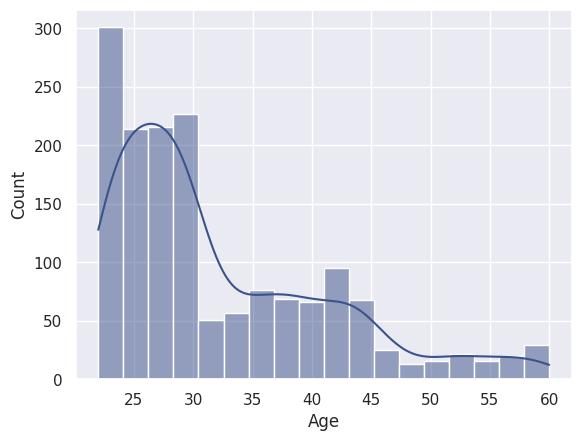

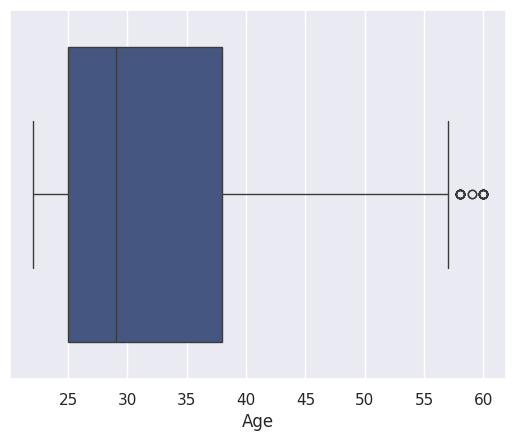

In [57]:
sns.histplot(data=df,x='Age', kde=True)
plt.show()
sns.boxplot(data=df,x='Age')
plt.show()



*   The distribution of age is right skewed.
*   There are some outliers.
*   There is a significant concentration of young costumers, 25% of them are between 22 and 25 years old.





**Gender**

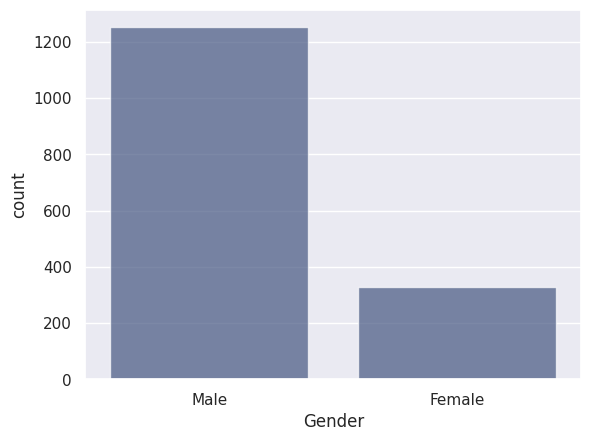

In [58]:
sns.countplot(data=df,x='Gender', alpha=0.7)
plt.show()



*   Male buyers are more than three times as prevalent as female buyers.



**Profession**

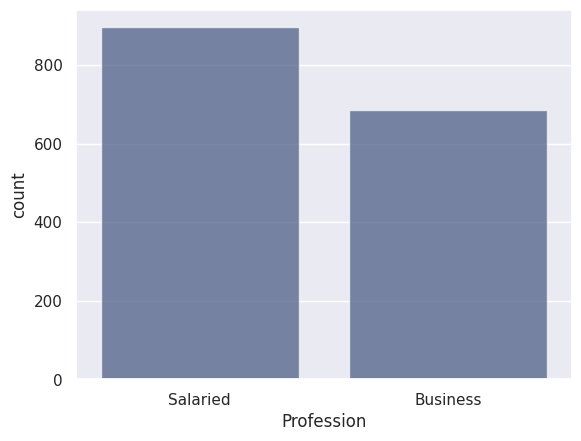

In [59]:
sns.countplot(data=df,x='Profession', alpha=0.7)
plt.show()

*   Almost 700 buyers are business owners, while around 900 are salaried.

**Marital status**

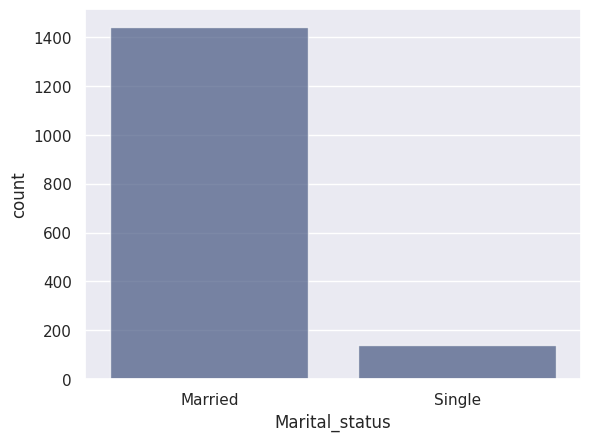

In [60]:
sns.countplot(data=df,x='Marital_status', alpha=0.7)
plt.show()



*   Most customers are married, they comprise more than 1400 while single buyers do not even get to 200.



**Education**

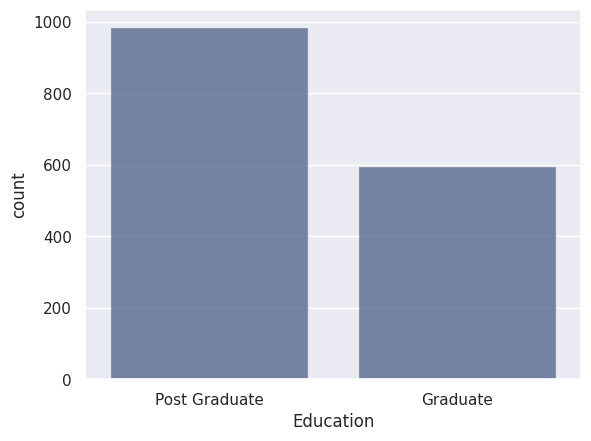

In [61]:
sns.countplot(data=df,x='Education', alpha=0.7)
plt.show()

*   All customers in the dataset are either Graduates or Post Graduates.
*   Post Graduates are most prevalent with almost 1000 entries compared to almost 600 Graduates.




**Number of dependents**





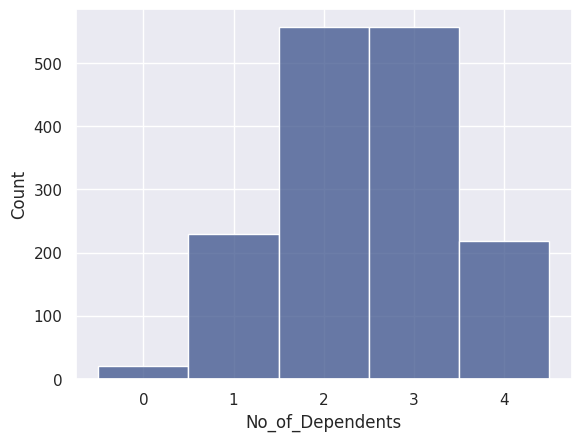

In [62]:
sns.histplot(data=df,x='No_of_Dependents', discrete=True)
plt.show()

*   Only a very small portion of buyers have no dependents.
*   Most of them have either two or three dependents.
*   The rest have either 1 or 4 dependents.

**Personal loan**

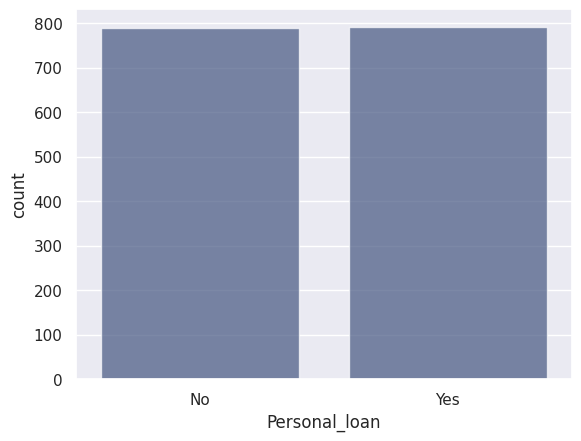

In [63]:
sns.countplot(data=df,x='Personal_loan', alpha=0.7)
plt.show()

*   Customers are almost perfectly divided between those who have a personal loan a those who do not.






**House loan**

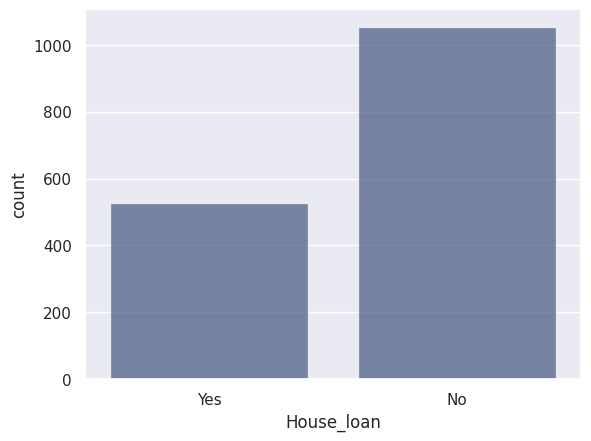

In [64]:
sns.countplot(data=df,x='House_loan', alpha=0.7)
plt.show()

*   More than a thousand buyers do not have a house loan, while around 500 do.




**Partner working**

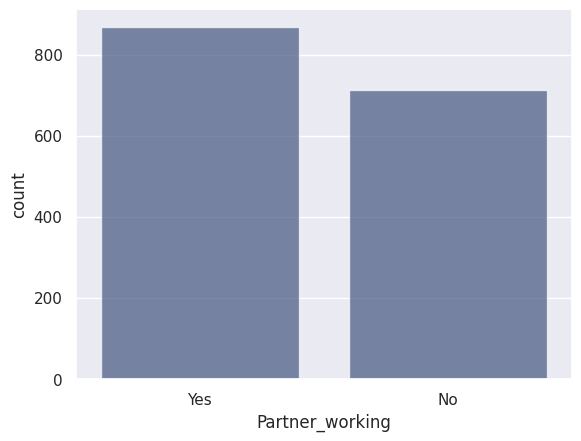

In [65]:
sns.countplot(data=df,x='Partner_working', alpha=0.7)
plt.show()

*   Around 900 of buyers have a partner that also works, while around 700 have one that does not.




**Salary**

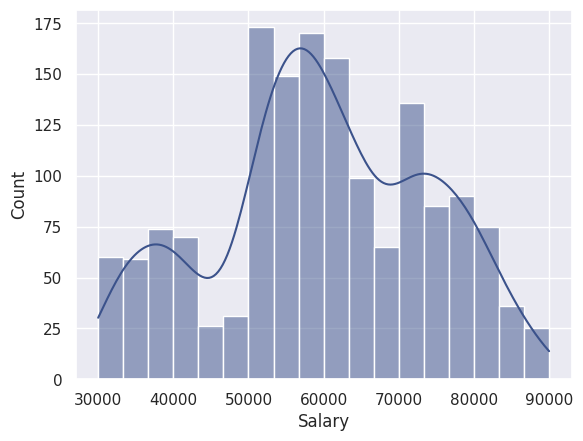

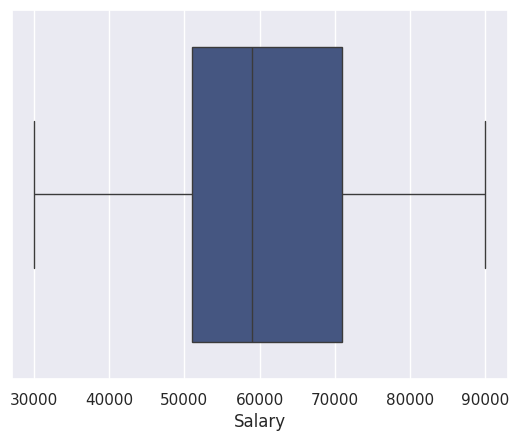

In [66]:
sns.histplot(data=df,x='Salary', kde=True)
plt.show()
sns.boxplot(data=df,x='Salary')
plt.show()

*   Most customers have a salary that ranges between 51k and 71k, with both the mean and median being around 59k.
*   The rest are on a wider spread between 30k-51k and 71k-90k.



**Partner salary**

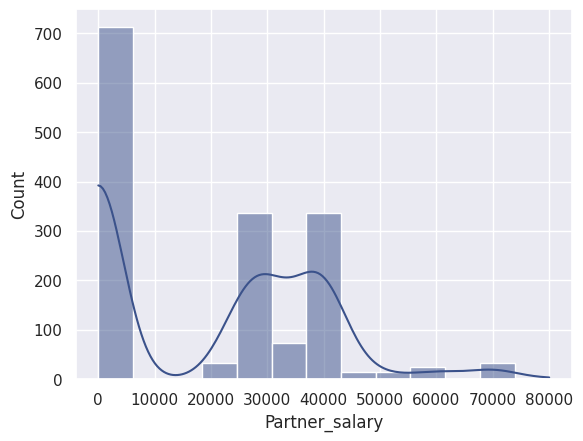

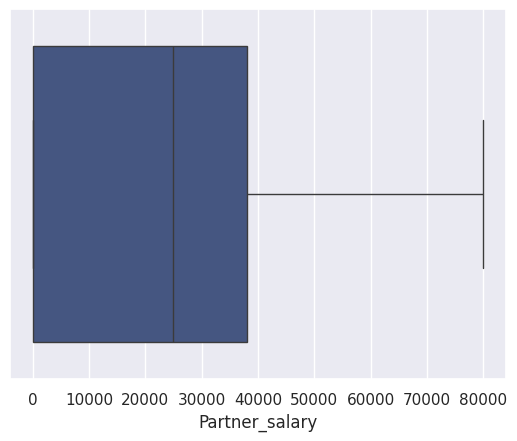

In [67]:
sns.histplot(data=df,x='Partner_salary', kde=True)
plt.show()
sns.boxplot(data=df,x='Partner_salary')
plt.show()

*   Most partners have no salary, which coincides with the information on the 'Partner_working' column, since all of those who are not working would represent the concentration of data at the start of this graph.
*   Out of the ones working, they mostly make between 25k and 45k, with some skew to the right after that.



**Total salary**

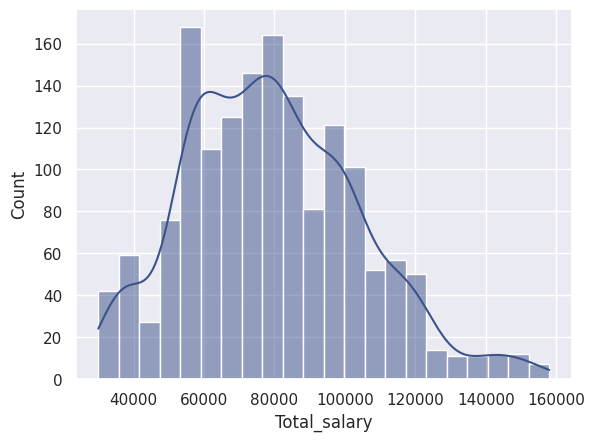

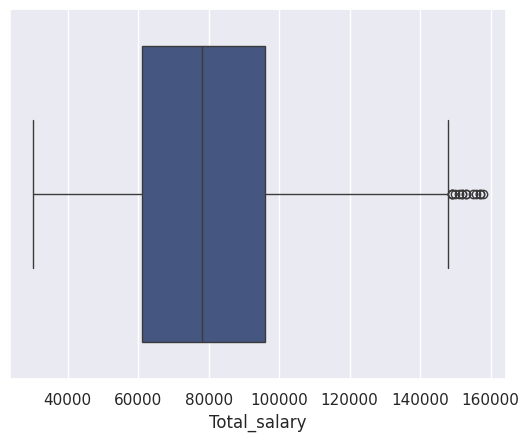

In [68]:
sns.histplot(data=df,x='Total_salary', kde=True)
plt.show()
sns.boxplot(data=df,x='Total_salary')
plt.show()

*   Total salary has a very slight right skew.
*   The mean for total salary is around 79.5k
*   The median is 78k, this clossenes between mean and median confirms an almost symmetrical distribution.





**Price**

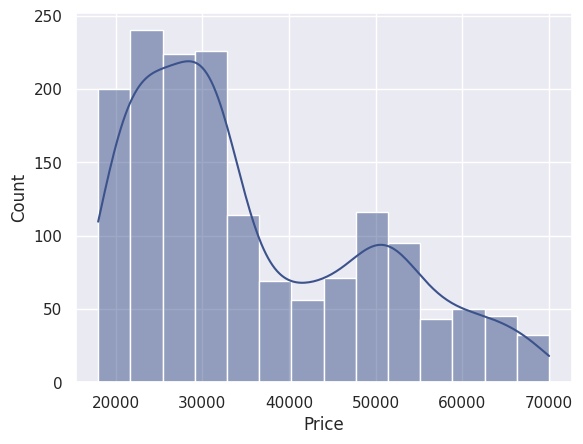

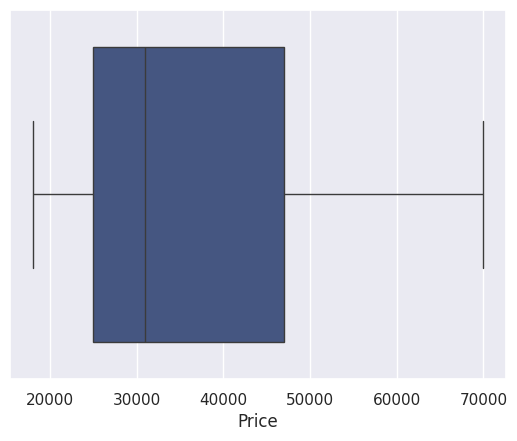

In [69]:
sns.histplot(data=df,x='Price', kde=True)
plt.show()
sns.boxplot(data=df,x='Price')
plt.show()

*   Price is right skewed, with a bump at around 50k.
*   Median is 31k and mean is around 35k.



**Make**

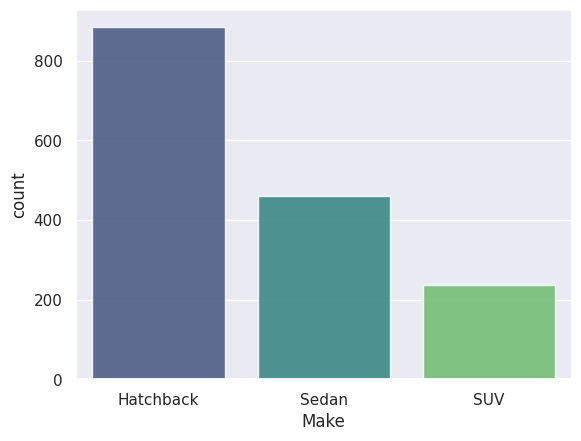

In [70]:
sns.countplot(data=df,x='Make', alpha=0.85, palette="viridis")
plt.show()

*   Hatchback is the most prevalent make with almost 900 units sold.
*   Sedan is almost 500 and SUV a little above 200.



#### Question 7: How many cars are of make Hatchback and priced above 25000. State your observations? [2 marks]

In [71]:
len(df[(df['Make'] == 'Hatchback') & (df['Price'] > 25000)])

444

#### Observations: **444 cars sold are Hatchbacks priced above 25,ooo.**


#### Question 8: How many owners have bought cars that were priced higher than their salary. How many of them have taken personal loan? [3 marks]

In [72]:
df_pricing = df[df['Price'] > df['Salary']]
print(len(df_pricing), 'owners  have bought cars that were priced higher than their salary.')
print(len(df_pricing[df['Personal_loan']=='Yes']), 'of them took a personal loan')

96 owners  have bought cars that were priced higher than their salary.
44 of them took a personal loan


#### Observations: **96 owners  have bought cars that were priced higher than their salary. 44 of those 96 took a personal loan.**




---



### Multivariate Analysis

#### Question 9: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [15 marks]

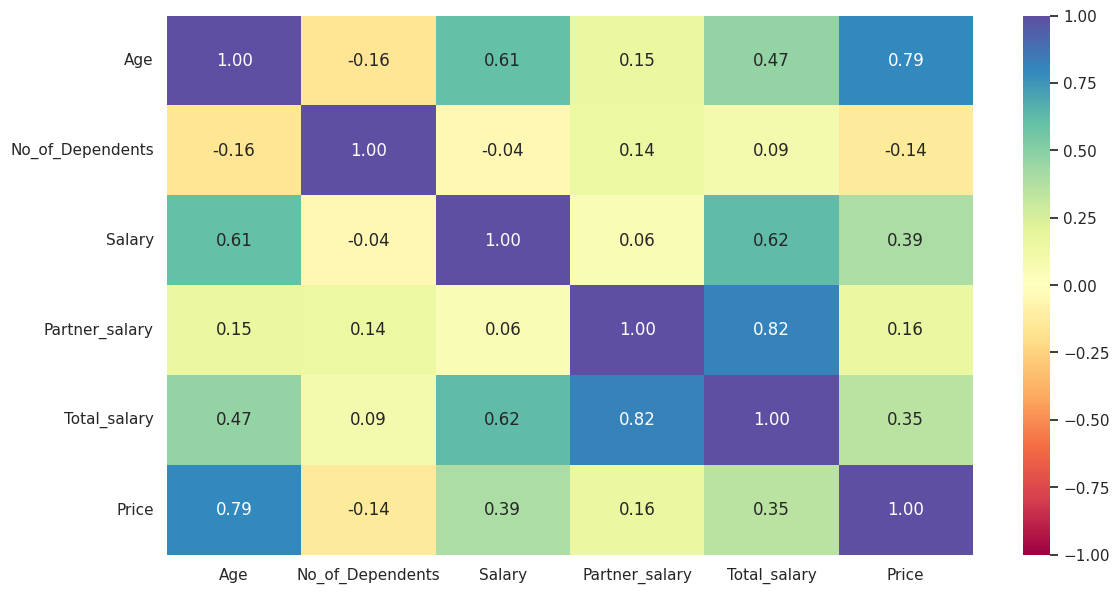

In [73]:
plt.figure(figsize=(13, 7))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

In [74]:
len(df[df["Partner_salary"]==0])

713

*   Partner salary and total salary are mostly correlated because 713 entries have partner salary as 0. So naturally as Partner salary increases, the sum of it with the customer's salary does so as well.
*   Also it seems that the older a customer gets, the more they spend on their car.
*   As well the older the customer is, the higher their salary tends to be.
*   There is some correclation between Salary and Price, which is logical.
*   Most other variables do not present significant correlation.

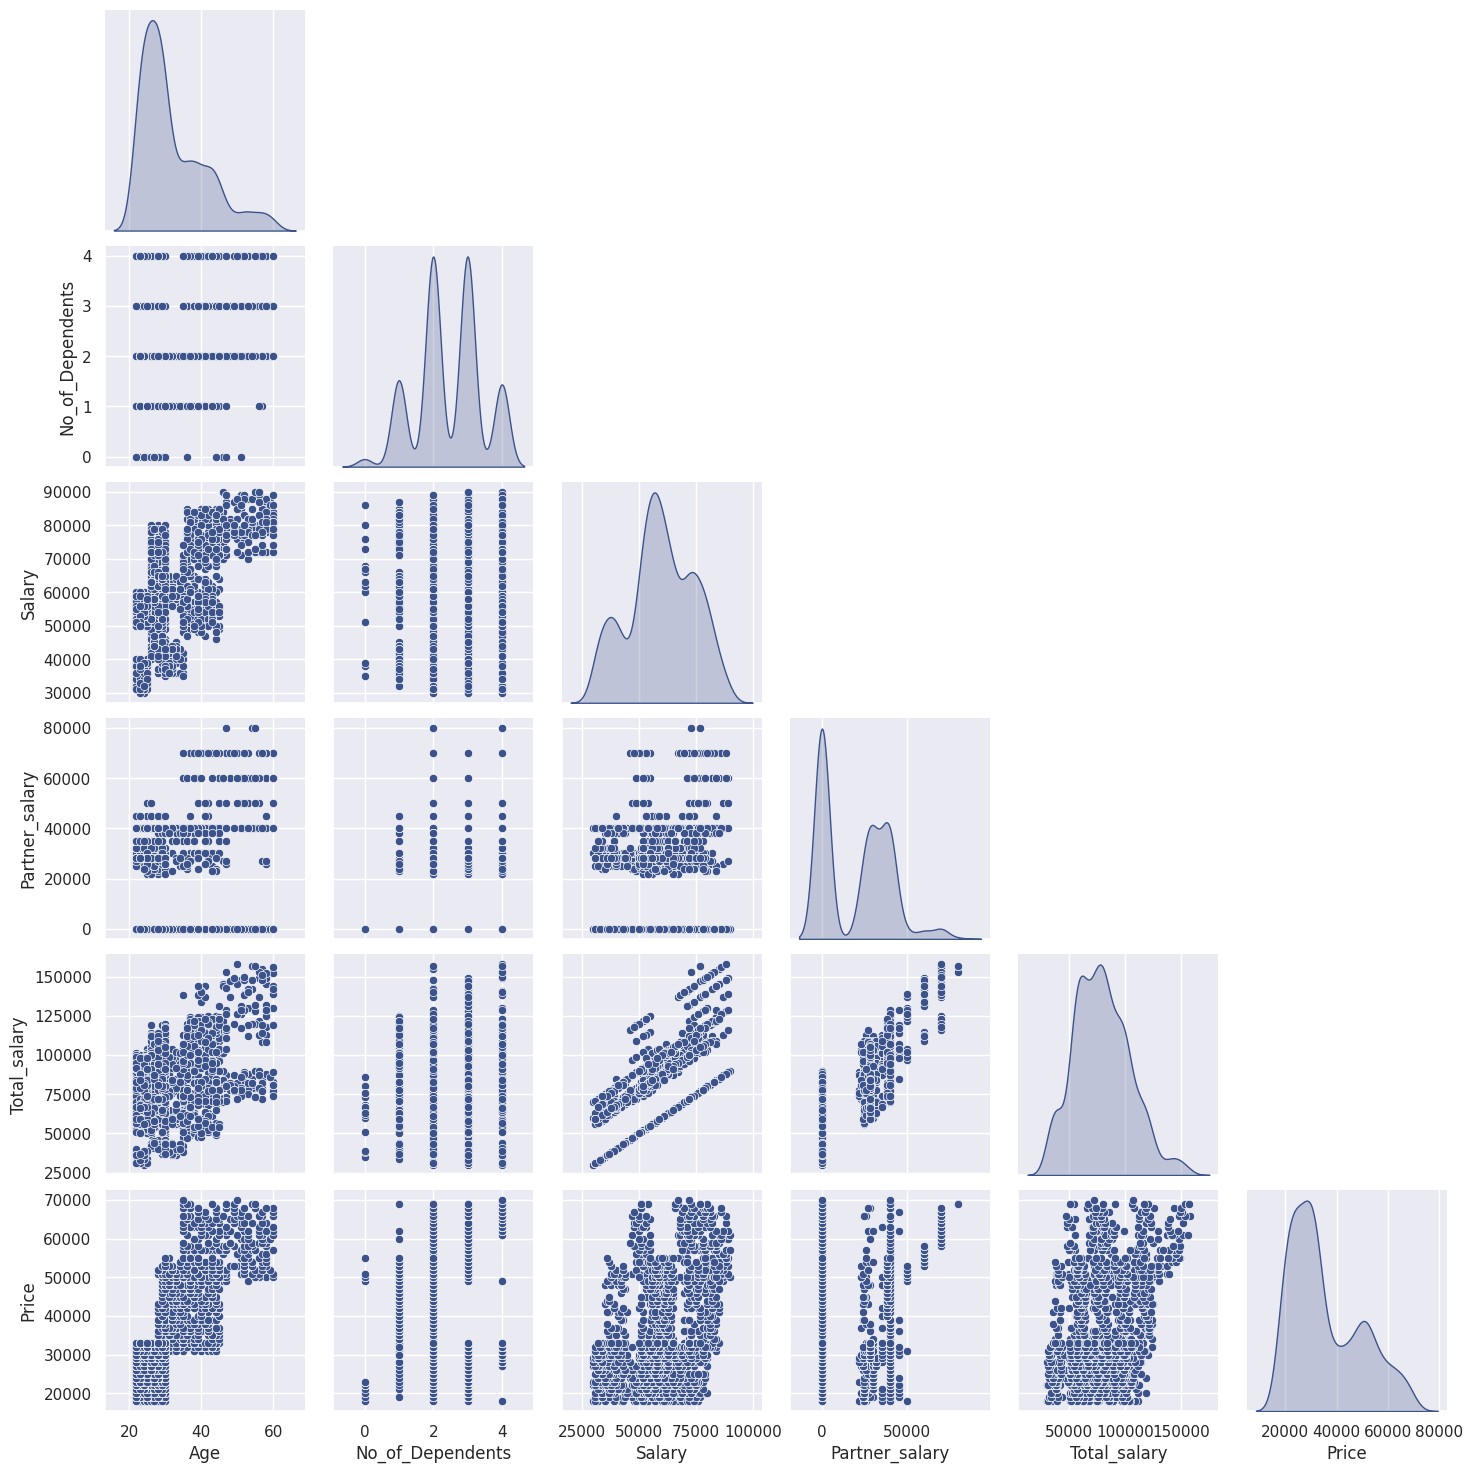

In [75]:
sns.pairplot(data=df, diag_kind = "kde", corner='True')
plt.show()

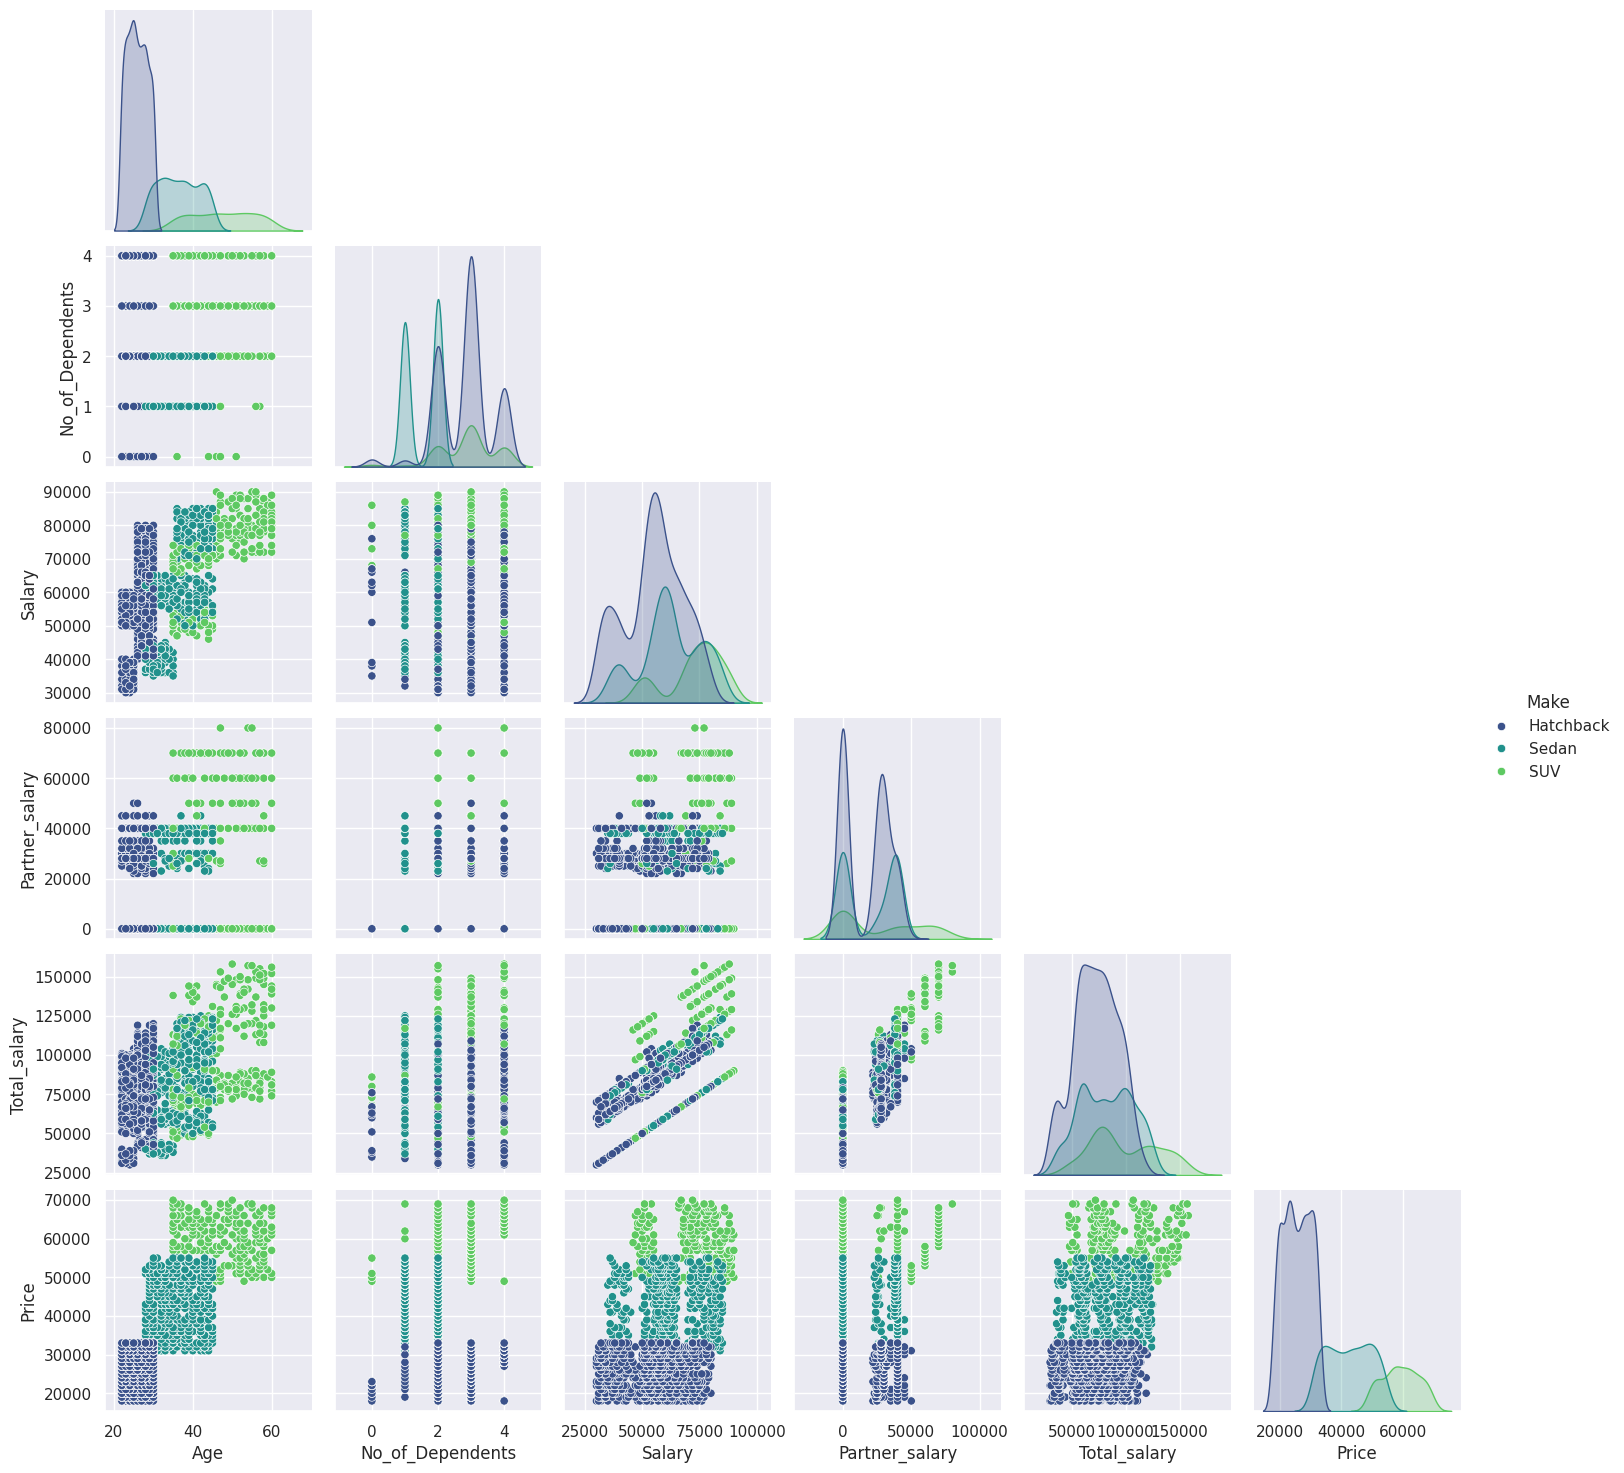

In [76]:
sns.pairplot(data=df, hue = "Make", diag_kind = "kde", corner='True')
plt.show()

*   Here we confirm there is some correlation between age and salary.
*   Introducing the type of make presents interesting data. Make seems highly correlated to both price and age. As younger customers go for low priced hatchbacks, middle aged customers go for middle priced sedans and older customers go for higher priced SUV's.
*   All makes seem heavily tied to certain age groups, but makes are not really tied customer's salary.



Make - Price

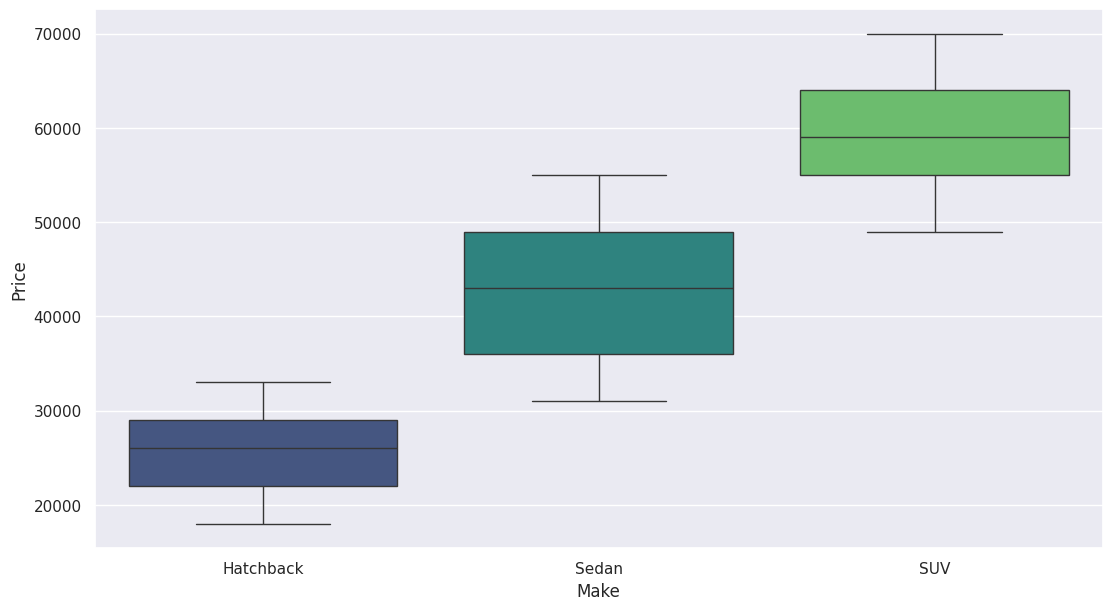

In [77]:
plt.figure(figsize=(13,7))
sns.boxplot(data=df, x="Make", y="Price", palette="viridis")
plt.show()

*   Here we confirm something simple, the general order for pricing is hatchback at the lowest prices, sedan at the mid range and SUV's the highest priced.




Make - Age

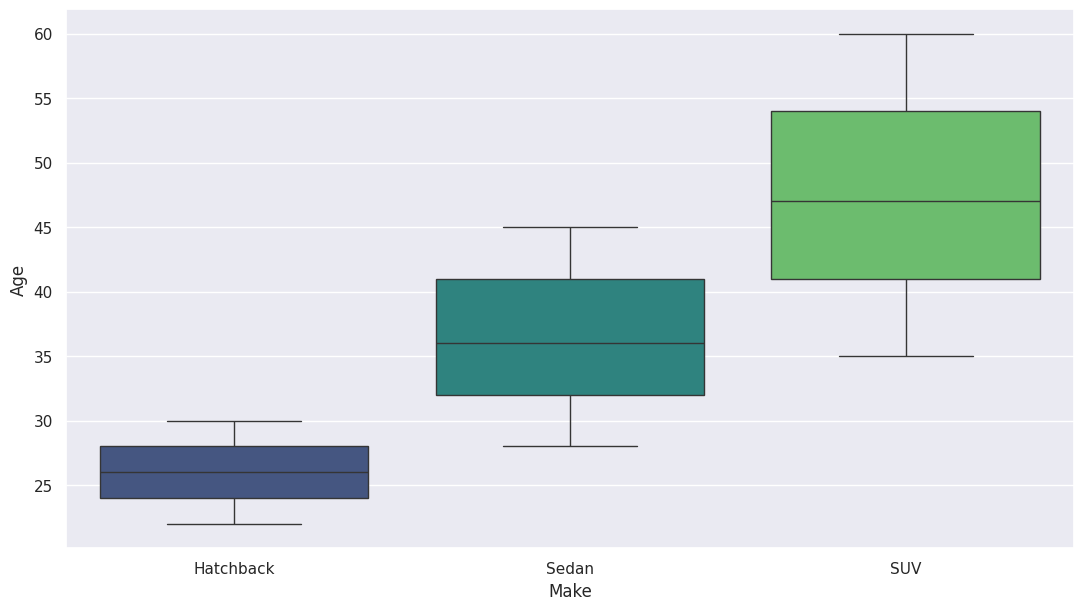

In [78]:
plt.figure(figsize=(13,7))
sns.boxplot(data=df, x="Make", y="Age", palette="viridis")
plt.show()

*   We can clearly confirm here how age is highly correlated to make.




Make - Salary

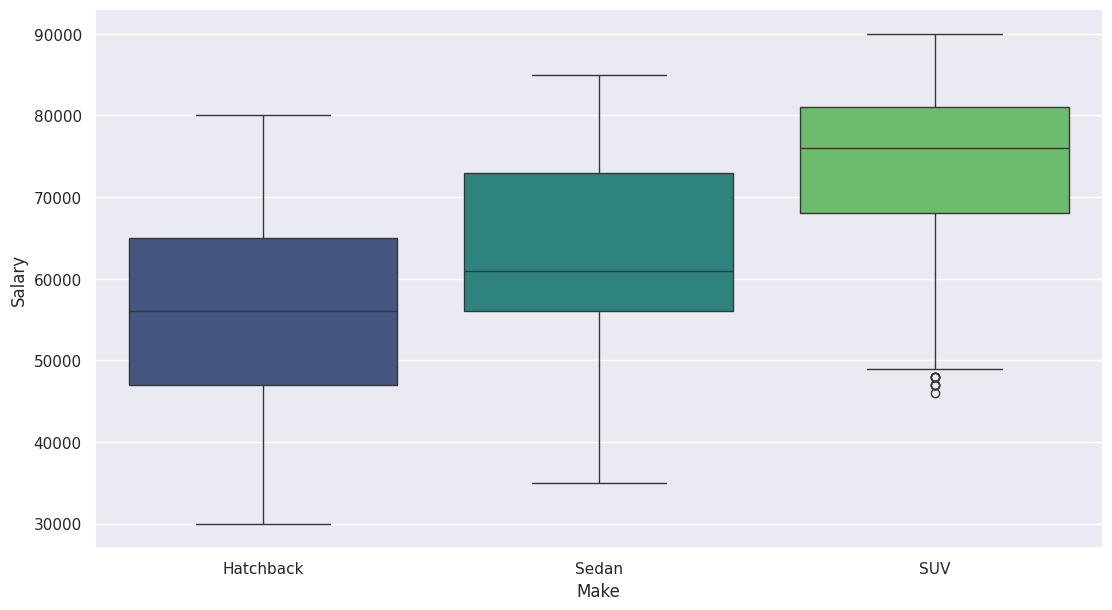

In [79]:
plt.figure(figsize=(13,7))
sns.boxplot(data=df, x="Make", y="Salary", palette="viridis")
plt.show()

*   In this boxplot we observe a slight correlation between make and salary, but the distribution of all three makes is more widely spread. Age remains quite more relevant than salary when it comes to choosing a certain type of car make.




Make - Education

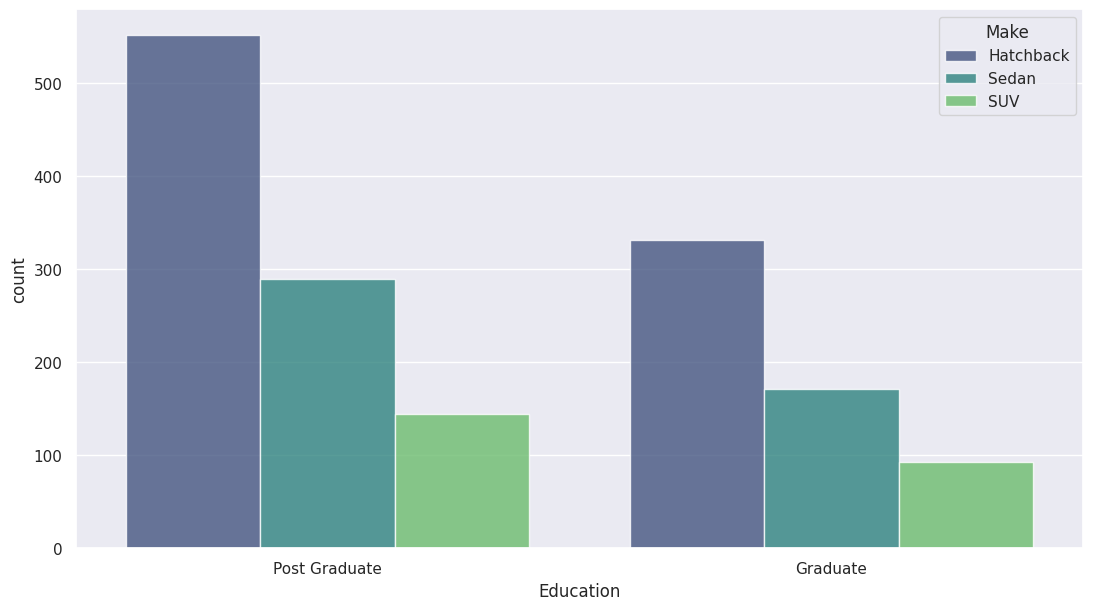

In [80]:
plt.figure(figsize=(13,7))
sns.countplot(data=df, x="Education", hue="Make", alpha=0.8)
plt.show()

*   Here we see that hatchbacks are the most sold, followed by sedans and finally SUV's. That order is kept between graduate and post-graduate clients as well as roughly the same proportion between them, so this correlation must be low.



Make - Profession

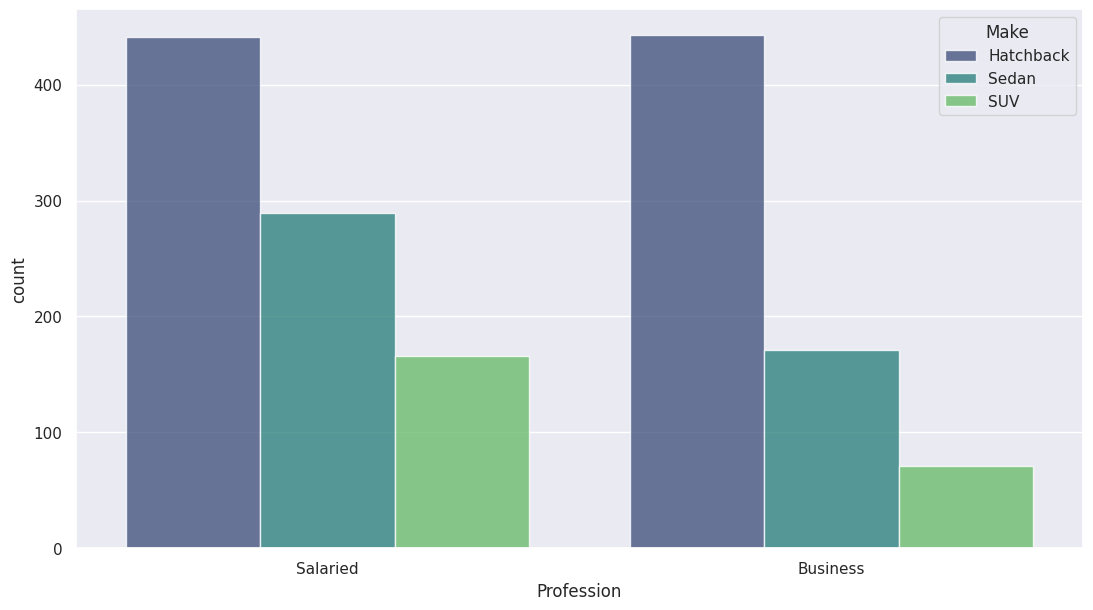

In [81]:
plt.figure(figsize=(13,7))
sns.countplot(data=df, x="Profession", hue="Make", alpha=0.8)
plt.show()

*   The same order is kept between salaried clients and business owners, although here we do see by proportion that business owners prefer hatchbacks more than salaried clients.



Make - Number of dependents

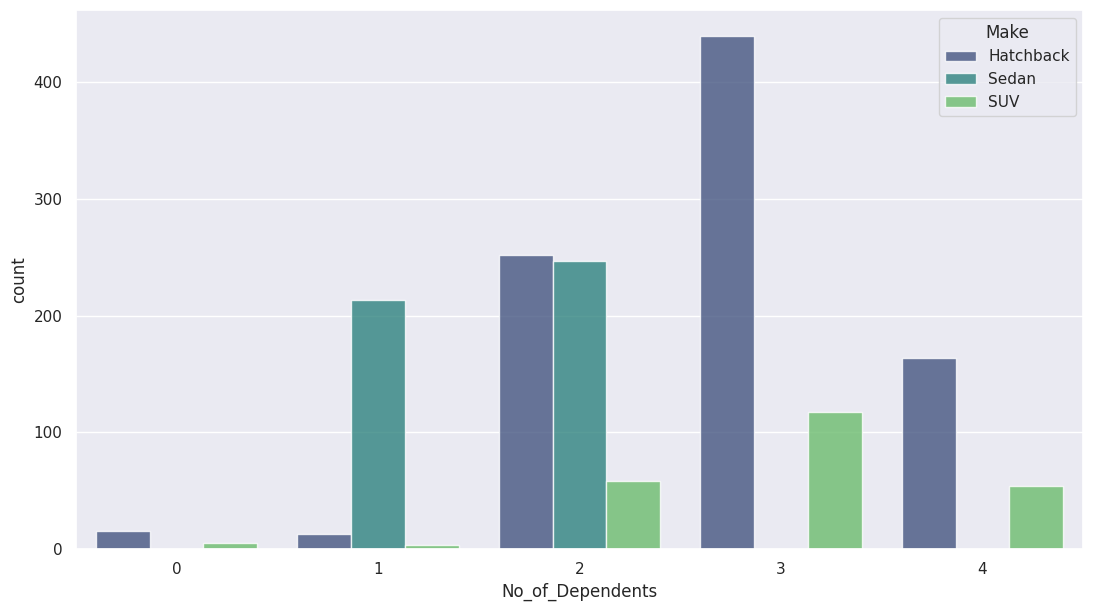

In [82]:
plt.figure(figsize=(13,7))
sns.countplot(data=df, x="No_of_Dependents", hue="Make", alpha=0.8)
plt.show()

*   In this dataset, clients with zero dependents buy either hatchbacks or SUV's, but not sedans. We can also conclude that there are very little clients with no dependents.
*   Clients with one dependent have a strong preference for sedans.
*   Clients with two dependents buy mostly either hatchbacks or sedans, some of them buy SUV's.
*   Clients with three dependents buy mostly hatchbacks, some of them buy SUV's and none buy sedans.
*   Finally, clients with four dependents also mostly buy hatchbacks, some of them buy SUV's and none buy sedans.








Make - Personal loan

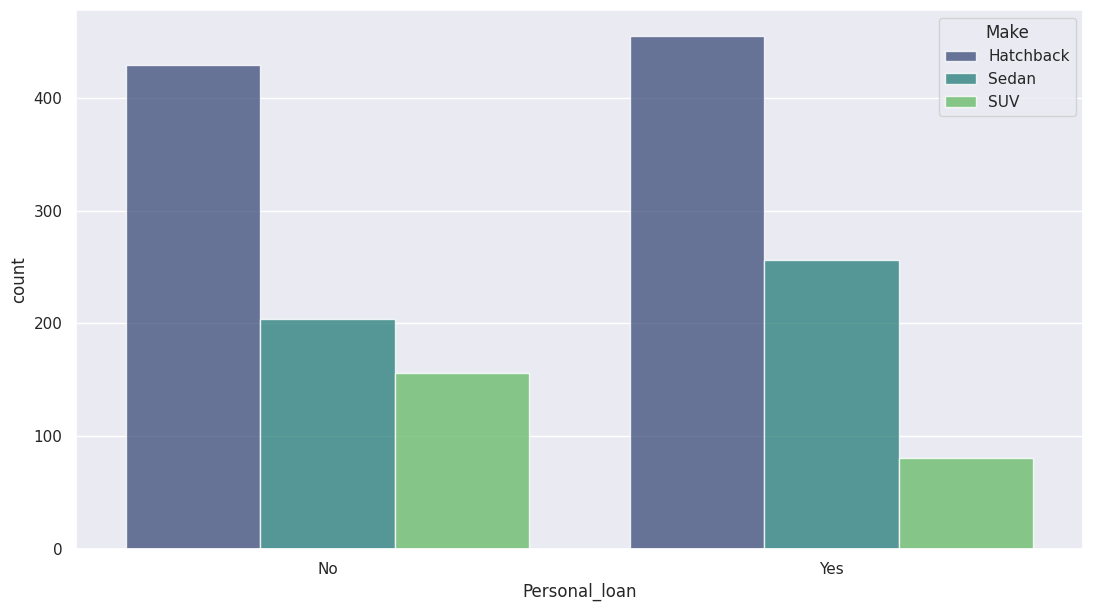

In [83]:
plt.figure(figsize=(13,7))
sns.countplot(data=df, x="Personal_loan", hue="Make", alpha=0.8)
plt.show()

*   Here we see that there is not much of a correlation between make and personal loan.




Make - House loan

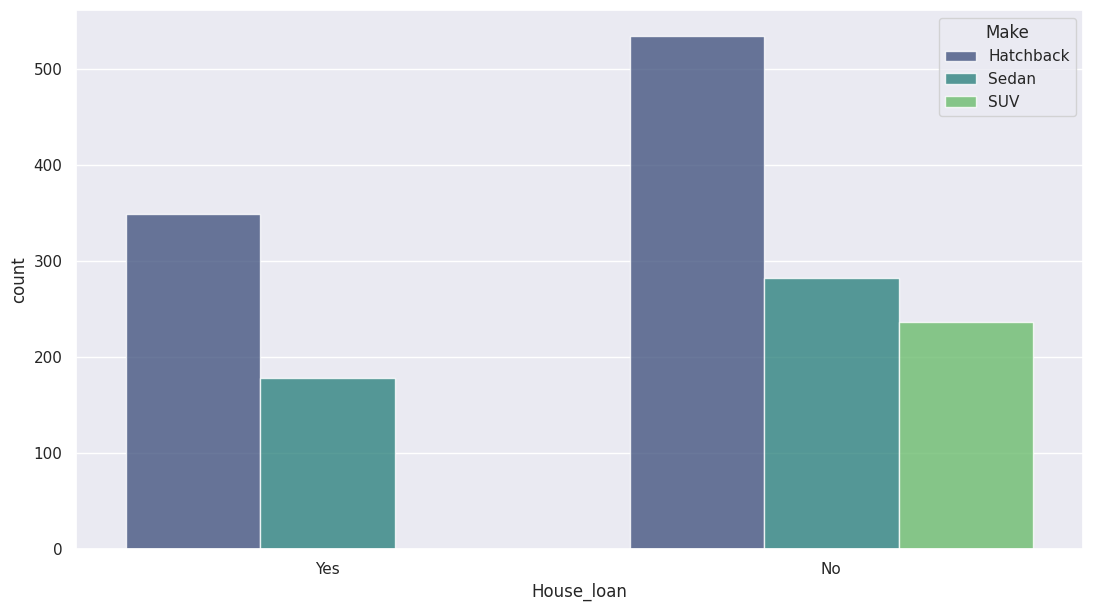

In [84]:
plt.figure(figsize=(13,7))
sns.countplot(data=df, x="House_loan", hue="Make", alpha=0.8)
plt.show()

*   Clients who have taken a  house loan do not buy SUV's, and also in general are less common car buyers.



Make - Gender

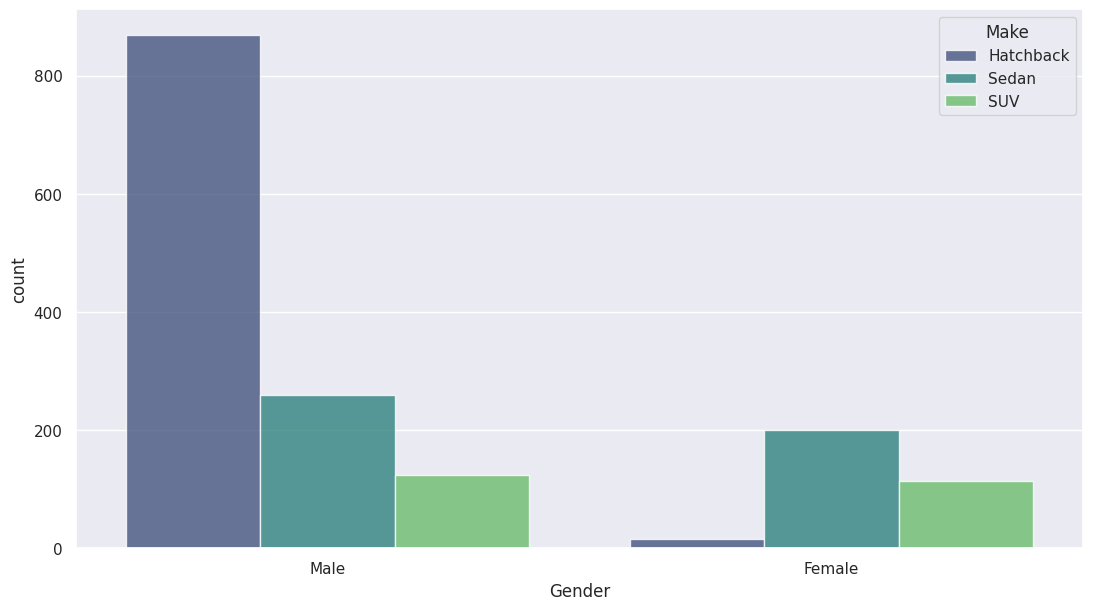

In [85]:
plt.figure(figsize=(13,7))
sns.countplot(data=df, x="Gender", hue="Make", alpha=0.8)
plt.show()

*   Most hatchbacks are bought by men.
*   Sedans and SUV's are almost equally bought by men and women.



Make - Marital status

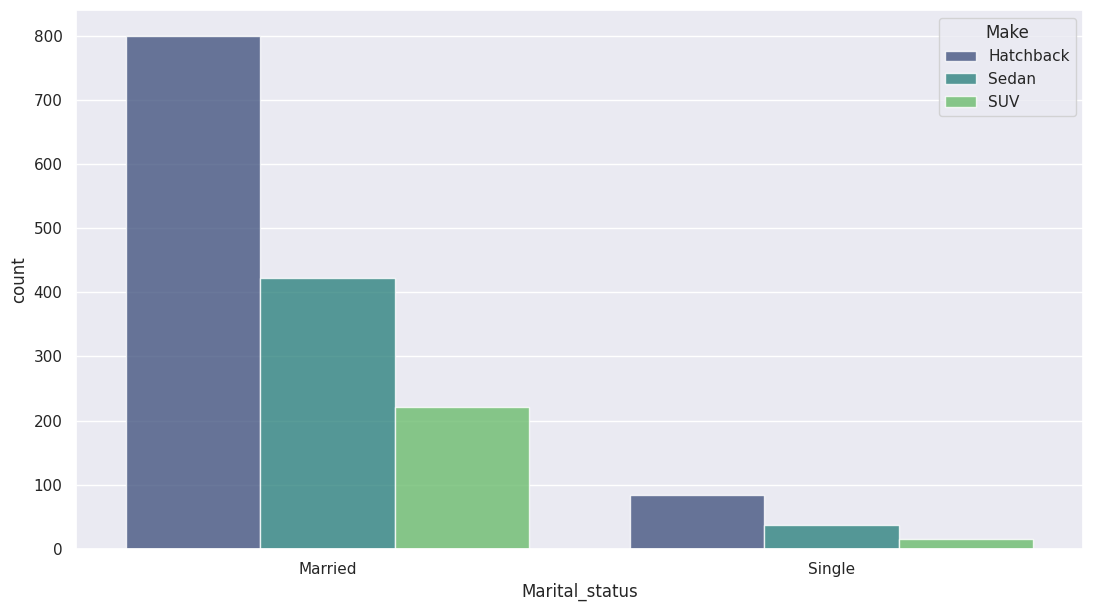

In [86]:
plt.figure(figsize=(13,7))
sns.countplot(data=df, x="Marital_status", hue="Make", alpha=0.8)
plt.show()

*   Most clients across all makes are married.



Make - Partner working

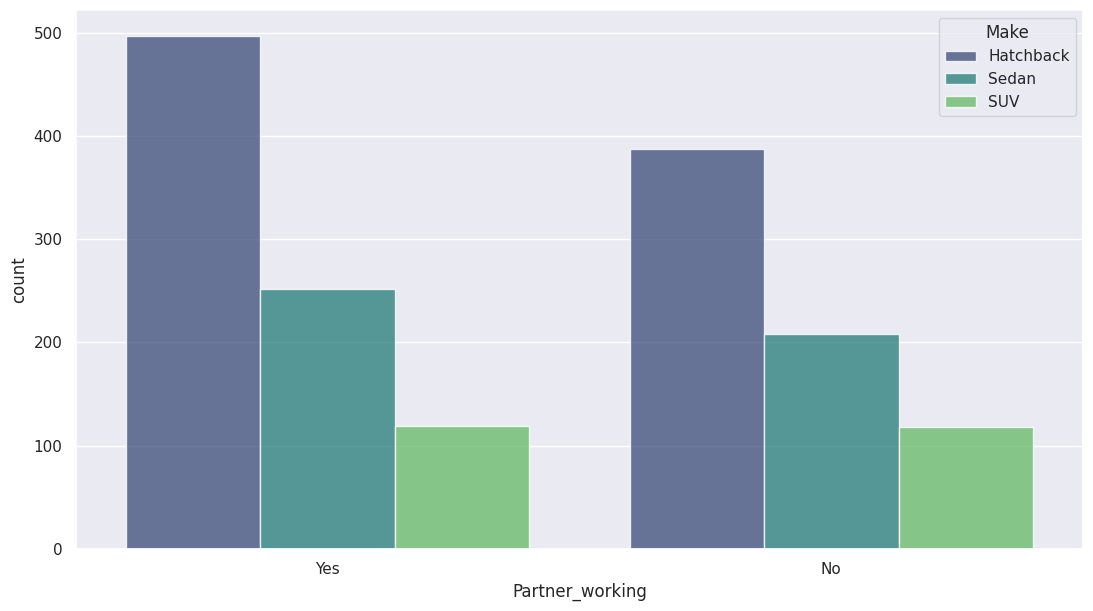

In [87]:
plt.figure(figsize=(13,7))
sns.countplot(data=df, x="Partner_working", hue="Make", alpha=0.8)
plt.show()

*   For sedan, and specially for hatchback buyers, it is a bit more likely that they have a working partner, as per the data.
*   For SUV buyers is about as likely that their partner is woking or not.





---



# **ROUGH BUYER PROFILES BY MAKE**

### **HATCHBACK BUYER PROFILE**

In [88]:
df[df["Make"]=="Hatchback"].describe(include="all")

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
count,884.000000,884,884,884,884,884.000000,884,884,884,884.000000,884.000000,884.000000,884.000000,884
unique,NaN,2,2,2,2,NaN,2,2,2,NaN,NaN,NaN,NaN,1
top,NaN,Male,Business,Married,Post Graduate,NaN,Yes,No,Yes,NaN,NaN,NaN,NaN,Hatchback
freq,NaN,869,443,800,552,NaN,455,535,497,NaN,NaN,NaN,NaN,884
mean,25.874434,NaN,NaN,NaN,NaN,2.820136,NaN,NaN,NaN,54969.457014,17707.013575,72676.470588,25561.085973,NaN
std,2.520373,NaN,NaN,NaN,NaN,0.806543,NaN,NaN,NaN,12798.737168,16250.833815,20078.257725,4425.257139,NaN
min,22.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,30000.000000,0.000000,30000.000000,18000.000000,NaN
25%,24.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,47000.000000,0.000000,58000.000000,22000.000000,NaN
50%,26.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,56000.000000,25000.000000,73000.000000,26000.000000,NaN
75%,28.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,65000.000000,30000.000000,88000.000000,29000.000000,NaN


**The most typycal Hatchback buyer is a 26 year old, married, business owner male. With 2 or 3 kids, a post graduate degree, a personal loan but not a house loan. He has an average salary of 55k, their partner usually works and the sum of their salary on average is around 72.6k. The hatchback he usually buys costs 25.5k.**

### **SEDAN BUYER PROFILE**

In [89]:
df[df["Make"]=="Sedan"].describe(include="all")

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
count,460.000000,460,460,460,460,460.000000,460,460,460,460.000000,460.000000,460.000000,460.000000,460
unique,NaN,2,2,2,2,NaN,2,2,2,NaN,NaN,NaN,NaN,1
top,NaN,Male,Salaried,Married,Post Graduate,NaN,Yes,No,Yes,NaN,NaN,NaN,NaN,Sedan
freq,NaN,259,289,422,289,NaN,256,282,252,NaN,NaN,NaN,NaN,460
mean,36.458696,NaN,NaN,NaN,NaN,1.536957,NaN,NaN,NaN,62213.043478,20028.260870,82241.304348,42671.739130,NaN
std,5.093080,NaN,NaN,NaN,NaN,0.499175,NaN,NaN,NaN,13195.787416,18584.355909,23929.007894,7096.507565,NaN
min,28.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,35000.000000,0.000000,36000.000000,31000.000000,NaN
25%,32.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,56000.000000,0.000000,61000.000000,36000.000000,NaN
50%,36.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,61000.000000,27000.000000,82000.000000,43000.000000,NaN
75%,41.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,73000.000000,38000.000000,101250.000000,49000.000000,NaN


**The most typycal Sedan buyer is a 36 year old, married, salaried male (although many females are also buyers). With 1 or 2 kids, a post graduate degree, with a personal loan and no house loan. An average salary of 62k, their partner usually works and the sum of their salary on average is around 82k. The sedan he usually buys is around 42.6k.**

### **SUV BUYER PROFILE**

In [90]:
df[df["Make"]=="SUV"].describe(include="all")

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
count,237.000000,237,237,237,237,237.000000,237,237,237,237.000000,237.000000,237.000000,237.000000,237
unique,NaN,2,2,2,2,NaN,2,1,2,NaN,NaN,NaN,NaN,1
top,NaN,Male,Salaried,Married,Post Graduate,NaN,No,No,Yes,NaN,NaN,NaN,NaN,SUV
freq,NaN,124,166,221,144,NaN,156,237,119,NaN,NaN,NaN,NaN,237
mean,47.603376,NaN,NaN,NaN,NaN,2.894515,NaN,NaN,NaN,72683.544304,26632.911392,99316.455696,59303.797468,NaN
std,7.733023,NaN,NaN,NaN,NaN,0.839600,NaN,NaN,NaN,12165.048890,28590.109059,30509.741833,5829.544340,NaN
min,35.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,46000.000000,0.000000,47000.000000,49000.000000,NaN
25%,41.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,68000.000000,0.000000,76000.000000,55000.000000,NaN
50%,47.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,76000.000000,25000.000000,89000.000000,59000.000000,NaN
75%,54.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,81000.000000,50000.000000,125000.000000,64000.000000,NaN


**The most typycal SUV buyer can be either male or female. Is 47 years old, married and salaried. 2, 3 or 4 kids, post graduate degree, with neither personal loan nor house loan. An average salary of 72k, their partner could work or not and usually contributes to the sum of their salaries for a total of 99k. He or she usually buys an SUV priced around 59.3k**

#### Question 10:For customers who have 3 or fewer dependents, how does the average car price vary by profession ? [2 marks]

In [91]:
df_dependents = df[df["No_of_Dependents"]<= 3]
df_profession = df_dependents.groupby(['Profession'])['Price'].mean().sort_values(ascending = False).reset_index()
df_profession

,Profession,Price
0,Salaried,37036.175711
1,Business,32830.220713


#### Observations: **For customers with 3 dependents or fewer, the average price of the car they buy changes depending on being a business owner or an employee. Salaried customers spend 37k on average while those who own a business spend 32.8k.**


#### Question 11: For customers who have availed a home loan and a personal loan, how does the price vary by profession? [3 marks]

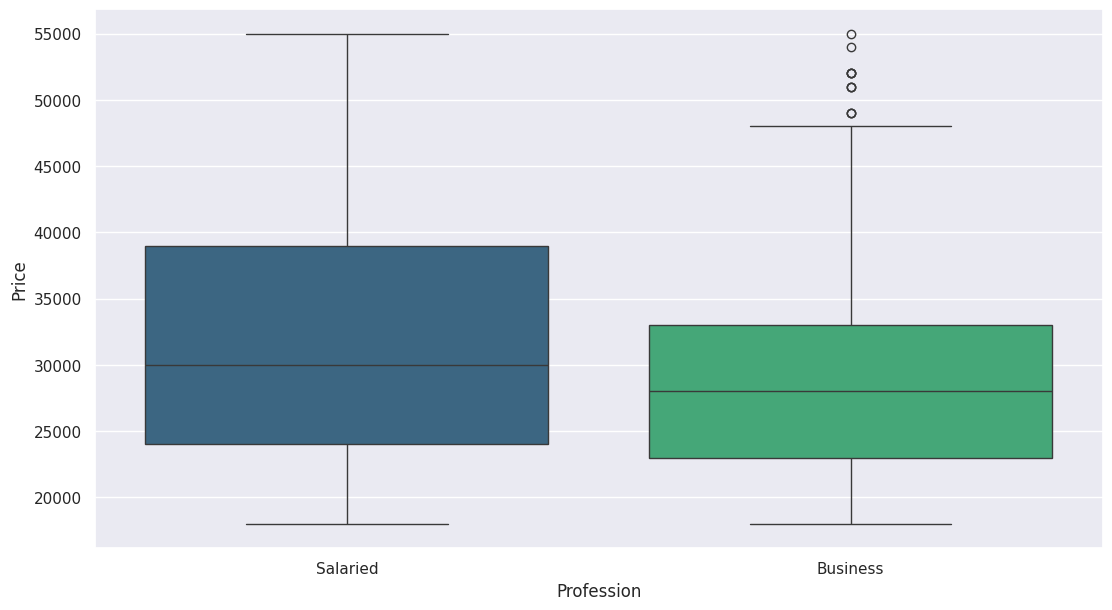

In [92]:
df_loan = df[(df['Personal_loan'] == 'Yes') & (df['House_loan'] == 'Yes')]

plt.figure(figsize=(13,7))
sns.boxplot(data=df_loan, x='Profession', y='Price', palette='viridis')
plt.show()

#### Observations: **For clients who have taken both a personal and house loan, salaried ones tend to spend more on their cars than business owners.**




---



## Conclusion and Recommendations

#### **Question 12:** Write the conclusions and business recommendations derived from the analysis. (6 marks)

A variety of profiles could be made taking different variables at the source of the analysis, yet profiling the buyers around the three company products present in the data gives a clear view of the market's characteristics; specially when accompanied by the previous analysis of single and paired variables.


# Detailed buyer profiles by make


---



> Here a more outlined version of a buyer profile for each car make is given.



### Task:
To compare and contrast the three buyer profiles (Hatchback, Sedan, SUV) to highlight their unique traits, overlapping characteristics, and significant differences. Identifying patterns and insights relevant to Austo's market entry.



---




**Hatchback Buyer Profile**
*   **Age:** Youngest (average 26 years old), predominantly 22-30.
*   **Gender:** Primarily Male (869 Male vs. 15 Female).
*   **Profession:** Balanced (443 business owners vs. 441 salaried)
*   **Marital Status:** Mostly Married.
*   **Education:** Post Graduate (around 62%)
*   **No. of Dependents:** Typically 2 or 3 dependents, with some 0 and 4.
*   **Personal Loan:** Slightly more likely to have a personal loan.
*   **House Loan:** More likely NOT to have a house loan.
*   **Partner Working:** Slightly more likely to have a working partner.
*   **Salary:** Lowest average individual salary (approx. 55k).
*   **Total Salary:** Lowest average household income (approx. 72.6k).
*   **Price:** Lowest average car price (approx. 25.5k).


---



**Sedan Buyer Profile**
*   **Age:** Middle-aged (average 36 years old), predominantly 28-45.
*   **Gender:** Balanced (259 Male vs. 201 Female).
*   **Profession:** Predominantly Salaried (around 63%).
*   **Marital Status:** Mostly Married.
*   **Education:** Post Graduate (around 63%).
*   **No. of Dependents:** Typically 1 or 2 dependents.
*   **Personal Loan:** Slightly more likely to have a personal loan.
*   **House Loan:** More likely NOT to have a house loan.
*   **Partner Working:** Slightly more likely to have a working partner.
*   **Salary:** Mid-range average individual salary (approx. 62k).
*   **Total Salary:** Mid-range average household income (approx. 82k).
*   **Price:** Mid-range average car price (approx. 42.6k).


---



**SUV Buyer Profile**
*   **Age:** Oldest (average 47 years old), predominantly 35-60.
*   **Gender:** Balanced (124 Male vs. 113 Female).
*   **Profession:** Predominantly Salaried (around 70%).
*   **Marital Status:** Mostly Married.
*   **Education:** Post Graduate (around 61%).
*   **No. of Dependents:** Typically 2, 3 or 4 dependents.
*   **Personal Loan:** More likely NOT to have a personal loan.
*   **House Loan:** Does NOT have a house loan.
*   **Partner Working:** Balanced likelihood of having a working partner or not.
*   **Salary:** Highest average individual salary (approx. 72k).
*   **Total Salary:** Highest average household income (approx. 99k).
*   **Price:** Highest average car price (approx. 59.3k).


---



### Common Traits and Overlapping Characteristics
*   **Marital Status:** All three profiles are predominantly **Married**.
*   **Education:** All three profiles have a majority of **Post Graduate** individuals.
*   **House Loan:** The majority of buyers across all categories do not have a house loan, with SUV buyers having no house loans.
*   **Professional Segmentation:** Both Salaried and Business professionals are present in all categories, though their proportions vary.

### Significant Differences and Unique Traits
*   **Age and Price Correlation:** A strong positive correlation exists between buyer age and car price. Hatchback buyers are the youngest and buy the cheapest cars, Sedan buyers are middle-aged with mid-priced cars, and SUV buyers are the oldest with the most expensive cars.
*   **Gender Distribution:** Hatchback buyers are overwhelmingly male, while Sedan and SUV buyers show a more balanced gender distribution.
*   **Profession:** Hatchback buyers lean very slightly towards Business professionals, whereas Sedan and SUV buyers are predominantly Salaried.
*   **Number of Dependents:** Hatchback and SUV buyers tend to have more dependents (2-4), while Sedan buyers mostly have fewer (1-2).
*   **Loan Status:** Personal loan distribution is fairly even for Hatchback and Sedan, but SUV buyers are less likely to have personal loans. SUV buyers notably have *no* house loans.
*   **Income Levels:** There's a clear progression in individual and total household income, directly corresponding to the car segment (Hatchback < Sedan < SUV).

### Key Patterns and Insights for Austo's Market Entry
1.  **Age-Based Market Segmentation:** Austo should target younger demographics (22-30) with cost-effective Hatchbacks, middle-aged customers (28-45) with Sedans, and older, more affluent customers (35-60) with SUVs. This implies marketing strategies tailored to each age group's lifestyle and financial capacity.
2.  **Financial Capacity and Car Choice:** There's a direct relationship between salary (individual and total household) and the price/type of car purchased. Austo can leverage this by positioning different car models at various price points to cater to different income brackets.
3.  **Gender-Specific Marketing for Hatchbacks:** Given the strong male dominance in the Hatchback segment, Austo's marketing for Hatchbacks could be more male-centric, while Sedan and SUV campaigns should appeal to a broader gender audience. Having said this, the imbalance could also suggest an unexplored market.
4.  **Family-Oriented Messaging:** The high number of dependents for Hatchback and SUV buyers suggests that family-centric features (space, safety, utility) could be strong selling points for these segments. Sedan buyers, with fewer dependents, might be more interested in performance or comfort.
5.  **Loan Status and Purchasing Power:** SUV buyers, who typically have higher incomes and no house loans, appear to have greater financial flexibility, indicating they are less price-sensitive and potentially open to premium features or higher-end models. Marketing for SUVs could focus on luxury, advanced features, and status rather than just affordability.

### Business Recommendations for Austo

Based on the analysis and synthesized buyer profiles, here are actionable business recommendations for Austo:

#### 1. Hatchback Recommendations

*   **Marketing Strategies:**
    *   **Target Audience:** Young, married male business owners (around 26 years old) with 2-3 dependents and postgraduate degrees, who often have personal loans.
    *   **Messaging:** Emphasize affordability, practicality for small families (e.g., adequate space for 2-3 kids), fuel efficiency, and perhaps stylish designs that appeal to a younger, budget-conscious business professional. Highlight features that support daily commuting and light family use.
    *   **Channels:** Digital marketing campaigns on platforms popular with young professionals and small business owners, social media ads focusing on lifestyle and cost-effectiveness, partnerships with financial institutions for personal loan tie-ups.

*   **Product Positioning:**
    *   **Value Proposition:** Position Hatchbacks as the "Smart Start" car – an economical, versatile, and modern choice for young families and budding entrepreneurs. Focus on low running costs and entry-level luxury/technology.
    *   **Price Point:** Maintain the competitive price range of around $25,500, possibly offering attractive financing options given the propensity for personal loans.

*   **Potential Areas for Growth or Focus:**
    *   **Features:** Integrate modern infotainment systems, advanced safety features suitable for young families (e.g., child seat anchors, basic driver-assist features), and perhaps customizable interior options to appeal to individualistic business owners.
    *   **After-sales:** Offer attractive service packages and extended warranties to further reduce perceived cost of ownership.
    *   **Demographic Expansion:** Explore slight modifications or marketing angles to appeal to single young professionals or smaller families with fewer dependents if the market shows potential there.

#### 2. Sedan Recommendations

*   **Marketing Strategies:**
    *   **Target Audience:** Middle-aged (around 36 years old), married salaried males (and a good number of females) with 1-2 dependents and postgraduate degrees. They also tend to have personal loans.
    *   **Messaging:** Focus on comfort, reliability, executive styling, and a balance between family utility and professional image. Highlight features that enhance daily commutes and occasional family trips. Emphasize a step up in status from a hatchback.
    *   **Channels:** Targeted ads in professional journals/websites, family-oriented lifestyle magazines, online platforms catering to mid-career professionals, and dealership promotions that emphasize upgrade opportunities.

*   **Product Positioning:**
    *   **Value Proposition:** Position Sedans as the "Sophisticated Choice" – a reliable, comfortable, and stylish vehicle for established professionals and their growing families. It represents stability and practical elegance.
    *   **Price Point:** Maintain the mid-range price point of around $42,600, offering competitive loan rates or lease options.

*   **Potential Areas for Growth or Focus:**
    *   **Features:** Incorporate more advanced driver-assistance systems, premium interior finishes, enhanced fuel efficiency for longer commutes, and connectivity features important for professionals and families (e.g., larger touchscreens, integrated navigation).
    *   **Family-Friendly Additions:** Options for integrated entertainment systems for rear passengers or more versatile trunk space.

#### 3. SUV Recommendations

*   **Marketing Strategies:**
    *   **Target Audience:** Older (around 47 years old), married salaried individuals (male or female) with 2-3 dependents and postgraduate degrees. They are less likely to have personal or house loans, indicating higher financial stability.
    *   **Messaging:** Highlight safety, spaciousness, versatility, and premium features. Emphasize adventure, family comfort, and a strong, secure presence. Focus on the ability to handle various terrains and provide a luxurious driving experience.
    *   **Channels:** High-end lifestyle magazines, premium online automotive review sites, targeted advertising towards affluent demographics, and exclusive dealership events.

*   **Product Positioning:**
    *   **Value Proposition:** Position SUVs as the "Premium Family Adventure" vehicle – offering safety, luxury, and the capability for both daily family life and adventurous getaways. It signifies success and a desire for comfort and capability.
    *   **Price Point:** Justify the higher price point (around $59,300) by emphasizing premium materials, advanced technology, and superior performance.

*   **Potential Areas for Growth or Focus:**
    *   **Features:** Focus on robust off-road capabilities (if relevant to the target segment), advanced luxury interior features (e.g., panoramic sunroofs, premium sound systems), comprehensive safety suites, and state-of-the-art autonomous driving features.
    *   **Sustainability:** Offer hybrid or electric SUV options to cater to environmentally conscious affluent buyers.
    *   **Service:** Provide concierge-level service experiences and exclusive benefits for SUV owners.



---



## Summary:

### Data Analysis Key Findings

*   **Hatchback Buyers:** Are the youngest (average 26 years old), predominantly male business owners with 2-3 dependents. They have the lowest average individual salary (\$55,000) and household income (\$72,600), purchasing the cheapest cars (average \$25,500). They are more likely to have a personal loan but not a house loan.
*   **Sedan Buyers:** Are middle-aged (average 36 years old), with a balanced gender distribution, primarily salaried, and have 1-2 dependents. Their average individual salary is \$62,000 and household income is \$82,000, buying mid-priced cars (average \$42,600). They also tend to have a personal loan but no house loan.
*   **SUV Buyers:** Are the oldest (average 47 years old), with balanced gender distribution, mainly salaried, and have 2-3 dependents. They boast the highest average individual salary (\$72,000) and household income (\$99,000), purchasing the most expensive cars (average \$59,300). Notably, they are less likely to have personal loans and have no house loans, indicating greater financial stability.
*   **Commonalities Across Profiles:** All three buyer segments are predominantly married and possess post-graduate degrees. A majority across all categories do not have a house loan.
*   **Significant Correlations:** A strong positive correlation exists between buyer age, income level (individual and household), and the average price of the car purchased across the Hatchback, Sedan, and SUV segments.
*   **Gender and Professional Differences:** Hatchback buyers are overwhelmingly male business owners or salaried professionals, while Sedan and SUV buyers exhibit a more balanced gender distribution and are primarily salaried professionals.

### Insights or Next Steps

*   **Targeted Marketing and Product Alignment:** Austo should segment its marketing efforts based on age and financial capacity, positioning Hatchbacks as an affordable "Smart Start" for young, budget-conscious entrepreneurs, Sedans as a "Sophisticated Choice" for established middle-aged professionals, and SUVs as a "Premium Family Adventure" for older, affluent families.
*   **Feature and Financing Customization:** Product development and financing options should reflect buyer profiles: focus on affordability and basic family features for Hatchbacks, balanced performance and comfort for Sedans, and luxury, advanced safety, and premium features for SUVs, leveraging the greater financial flexibility of SUV buyers.
